# Evaluasi Kinerja Kuantitatif Model AttentiveSkel-3D V2 (Per-Frame)

Notebook ini menghasilkan **bukti kuantitatif** kinerja model final `AttentiveSkel3DPerFrame` pada data uji (test set). Evaluasi dilakukan secara murni pada level frame (64 label per video).

## Metrik yang Dihitung

| Metrik | Keterangan |
|---|---|
| **Accuracy** | Proporsi frame yang diprediksi benar dari seluruh sampel uji |
| **Precision** | Dari semua frame yang diprediksi salah, berapa yang benar-benar salah |
| **Recall** | Dari semua frame yang sebenarnya salah, berapa yang terdeteksi |
| **F1-Score** | Harmonik mean Precision & Recall — metrik utama |
| **Confusion Matrix** | Visualisasi distribusi prediksi benar/salah per frame |

## Konfigurasi Evaluasi

| Parameter | Nilai |
|---|---|
| Model | `AttentiveSkel3DPerFrame` |
| Data | `manifest_v2.csv` (15% test set) |
| Shape Logits | `(Batch*64, 2)` setelah reshape |
| Shape Target | `(Batch*64)` setelah reshape |
| Label kelas | `0` = Gerakan Benar, `1` = Gerakan Salah |


In [32]:
# ============================================================
# 1. Import library yang dibutuhkan
# ============================================================
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Tambahkan root proyek ke sys.path
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import model V2 dan Class Dataset V2
from src.data.v2.dataset import PerFrameDataset
from src.models.v2.model_per_frame import AttentiveSkel3DPerFrame

print("[INFO] Import berhasil.")
print(f"[INFO] PyTorch  : {torch.__version__}")

[INFO] Import berhasil.
[INFO] PyTorch  : 2.5.1


In [33]:
# ============================================================
# 2. Setup device dan muat dataset test_loader
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device   : {device}")

MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "manifest_v2.csv"

# Pastikan Model Path V2 benar (Ganti jika nama model berbeda)
MODEL_PATH    = PROJECT_ROOT / "models" / "saved_models" / "v2" / "best_model_full.pth"

# 2.1 Muat dataset V2 secara penuh
full_dataset = PerFrameDataset(MANIFEST_PATH)
n_total = len(full_dataset)

# 2.2 Tentukan porsi data (Train: 70%, Val: 15%, Test: 15%)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)
n_test  = n_total - n_train - n_val

# 2.3 Bagi dataset secara acak (gunakan seed 42 agar setara dengan saat training)
generator = torch.Generator().manual_seed(42)
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

# 2.4 Buat DataLoader hanya untuk Test Set
test_loader = DataLoader(
    test_set, 
    batch_size=16, 
    shuffle=False, 
    num_workers=0
)

print(f"\n[INFO] Ukuran test set    : {n_test} sampel video")
print(f"[INFO] Total frame uji    : {n_test * 64} frame")

[INFO] Device   : cuda

[INFO] Ukuran test set    : 74 sampel video
[INFO] Total frame uji    : 4736 frame


In [34]:
# ============================================================
# 3. Inisialisasi model dan muat bobot
# ============================================================
model = AttentiveSkel3DPerFrame(
    use_spatial_prior=True,
    use_learned_spatial=True,
    use_temporal_attention=True
).to(device)

try:
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)
    print("[INFO] Bobot model V2 berhasil dimuat!")
except FileNotFoundError:
    print("[PERINGATAN] File model belum ada. Pastikan sudah menjalankan training V2.")

model.eval()

[INFO] Bobot model V2 berhasil dimuat!


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5224\575766512.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=devi

AttentiveSkel3DPerFrame(
  (learned_spatial_attention): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=32, out_features=128, bias=True)
    (3): Sigmoid()
  )
  (temporal_attention): Sequential(
    (0): Conv3d(128, 1, kernel_size=(1, 1, 1), stride=(1, 1, 1))
  )
  (conv_block_1): Sequential(
    (0): Conv3d(3, 32, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(1, 2, 1), stride=(1, 2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv3d(32, 64, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(2, 2, 1), stride=(2, 2, 1), paddi

In [35]:
# ============================================================
# 4. Loop inferensi per-frame (Reshape Logic)
# ============================================================
all_true_labels  = []
all_pred_labels  = []
all_probs = []

with torch.no_grad():
    for batch_data, batch_labels in test_loader:
        batch_data   = batch_data.to(device)    # (B, 64, 33, 3)
        batch_labels = batch_labels.to(device)  # (B, 64)

        # 1. Dapatkan Logits Per-Frame
        logits = model(batch_data)              # (B, 64, 2)

        # 2. Reshape / Flatten Logits dan Labels untuk evaluasi level frame
        logits_flat = logits.view(-1, 2)        # (B*64, 2)
        labels_flat = batch_labels.view(-1)     # (B*64)

        # 3. Prediksi
        preds_flat = logits_flat.argmax(dim=1)  # (B*64)
        probs_flat = torch.softmax(logits_flat, dim=1)[:, 1]

        all_true_labels.extend(labels_flat.cpu().numpy())
        all_pred_labels.extend(preds_flat.cpu().numpy())
        all_probs.extend(probs_flat.cpu().numpy())

all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)
all_probs = np.array(all_probs)

manual_acc = (all_true_labels == all_pred_labels).mean() * 100
print(f"[INFO] Inferensi selesai pada {len(all_true_labels)} total frame.")
print(f"[INFO] Akurasi Frame keseluruhan : {manual_acc:.2f}%")

[INFO] Inferensi selesai pada 4736 total frame.
[INFO] Akurasi Frame keseluruhan : 88.03%


In [36]:
# ============================================================
# 5. Laporan Klasifikasi & Evaluasi Berbasis Probabilitas
# ============================================================
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import pandas as pd
from IPython.display import display

CLASS_NAMES = ["Gerakan Benar (0)", "Gerakan Salah (1)"]

# Tambahkan argumen output_dict=True untuk format ke tabel
report_dict = classification_report(
    all_true_labels,
    all_pred_labels,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True
)

# Hitung ROC-AUC dan PR-AUC
roc_auc = roc_auc_score(all_true_labels, all_probs)
pr_auc = average_precision_score(all_true_labels, all_probs)

print(f"\n{'='*70}")
print(f"  LAPORAN KLASIFIKASI PER-FRAME — AttentiveSkel-3D V2")
print(f"{'='*70}")
print(f"  Accuracy Frame Keseluruhan : {manual_acc:.2f}%")
print(f"  ROC-AUC Score              : {roc_auc:.4f}")
print(f"  PR-AUC Score               : {pr_auc:.4f}")
print(f"{'='*70}\n")

# Buat Pandas DataFrame agar cantik
df_report = pd.DataFrame(report_dict).T

# Terapkan gradient styling dan sembunyikan index/kolom tak perlu bila diinginkan
# cmap='Blues' memberikan gradasi warna biru berdasarkan value
styled_report = df_report.style.background_gradient(cmap='Blues').format("{:.4f}")
display(styled_report)


  LAPORAN KLASIFIKASI PER-FRAME — AttentiveSkel-3D V2
  Accuracy Frame Keseluruhan : 88.03%
  ROC-AUC Score              : 0.9489
  PR-AUC Score               : 0.9569



,precision,recall,f1-score,support
Gerakan Benar (0),0.8501,0.8693,0.8596,1997.0000
Gerakan Salah (1),0.9031,0.8883,0.8956,2739.0000
accuracy,0.8803,0.8803,0.8803,0.8803
macro avg,0.8766,0.8788,0.8776,4736.0000
weighted avg,0.8808,0.8803,0.8804,4736.0000


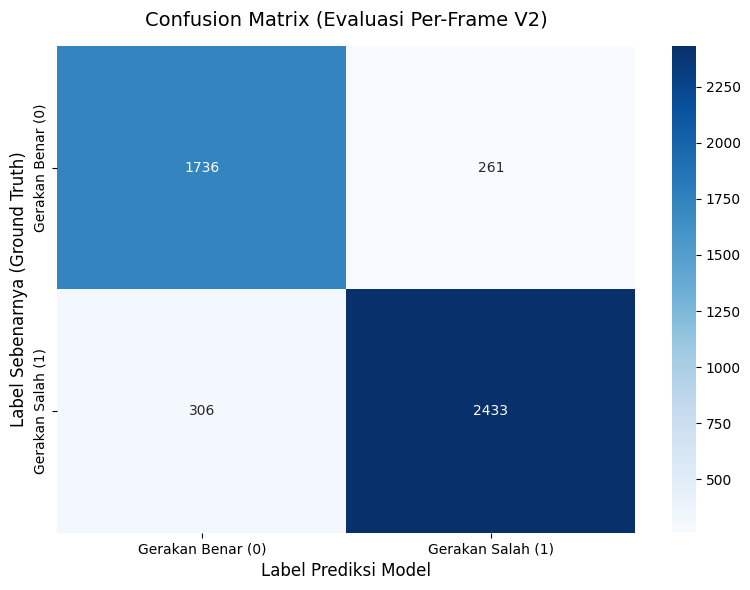

In [37]:
# ============================================================
# 6. Confusion Matrix
# ============================================================
cm = confusion_matrix(all_true_labels, all_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix (Evaluasi Per-Frame V2)", fontsize=14, pad=15)
plt.ylabel("Label Sebenarnya (Ground Truth)", fontsize=12)
plt.xlabel("Label Prediksi Model", fontsize=12)
plt.tight_layout()
plt.show()

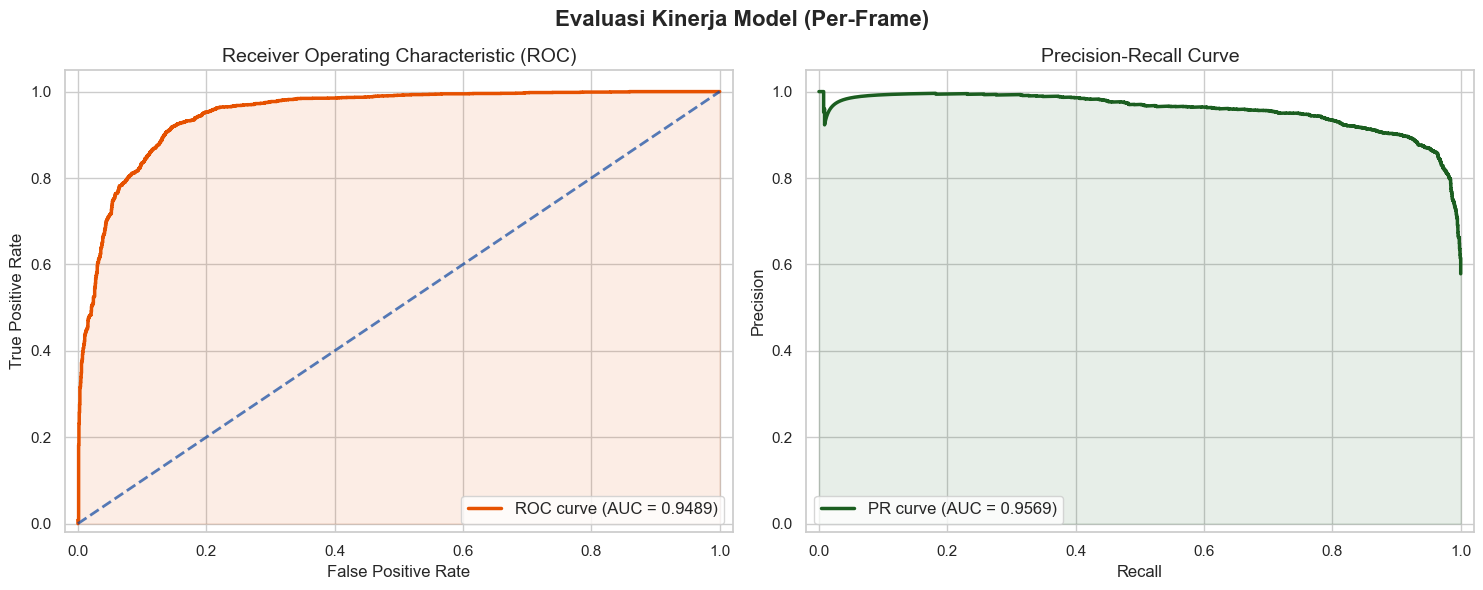

In [38]:
# ============================================================
# 6. Kurva ROC & Precision-Recall (Visualisasi Cantik)
# ============================================================
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Gunakan gaya visual Seaborn yang modern
sns.set_theme(style="whitegrid", palette="deep")

fpr, tpr, _ = roc_curve(all_true_labels, all_probs)
precision, recall, _ = precision_recall_curve(all_true_labels, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Evaluasi Kinerja Model (Per-Frame)", fontsize=16, fontweight="bold")

# --- ROC Curve ---
axes[0].plot(fpr, tpr, color="#E65100", lw=2.5, label=f"ROC curve (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="#0D47A1", lw=2, linestyle="--", alpha=0.7)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#E65100")
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=12, fontweight="500")
axes[0].set_ylabel("True Positive Rate", fontsize=12, fontweight="500")
axes[0].set_title("Receiver Operating Characteristic (ROC)", fontsize=14)
axes[0].legend(loc="lower right", fontsize=12, frameon=True)

# --- Precision-Recall Curve ---
axes[1].plot(recall, precision, color="#1B5E20", lw=2.5, label=f"PR curve (AUC = {pr_auc:.4f})")
axes[1].fill_between(recall, precision, alpha=0.1, color="#1B5E20")
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.05])
axes[1].set_xlabel("Recall", fontsize=12, fontweight="500")
axes[1].set_ylabel("Precision", fontsize=12, fontweight="500")
axes[1].set_title("Precision-Recall Curve", fontsize=14)
axes[1].legend(loc="lower left", fontsize=12, frameon=True)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()